# Ejercicio 7 - Práctica 6 - Parte 2

El dataset `USA_Housing.xlsx` contiene la siguiente información sobre un conjunto de 5000 viviendas en Estados Unidos:

- `avg_area_income`: ingreso promedio de los residentes de la ciudad en la que se encuentra la vivienda.
- `avg_area_house_age`: antigüedad promedio de las casas que se encuentran en la misma ciudad en la que se encuentra la vivienda.
- `avg_area_number_of_rooms`: número promedio de ambientes en las casas que se encuentran en la misma ciudad en la que se encuentra la vivienda.
- `avg_area_number_of_bedrooms`: número promedio de habitaciones en las casas que se encuentran en la misma ciudad de la vivienda.
- `area_population`: población de la ciudad de la vivienda.
- `price`: precio de venta de la vivienda.
- `address`: domicilio de la vivienda.

## PARTE I - Análisis exploratorio

1. Importe el dataset al entorno de trabajo y realice cualquier tarea de limpieza y adecuación del mismo que considere necesaria para su posterior análisis.
2. Realice un gráfico que le permita visualizar la distribución del precio de venta de las residencias que componen el dataset. En base al gráfico realizado, ¿cómo describiría la distribución de la variable en cuanto a sus características de simetría?
3. Construya un gráfico que le permita evaluar el grado de asociación lineal que existe entre las distintas variables cuantitativas que componen el dataset. En base al mismo, identifique la/s variable/s que se encuentran más fuertemente correlacionadas e informe e interprete la medida de asociación lineal correspondiente.
4. Elija uno de los pares de variables que identificó en el ítem anterior y realice un gráfico que le permita visualizar la relación general que existe entre las mismas.

## PARTE II - Ajuste de modelo

El objetivo principal de esta segunda parte es analizar si es factible ajustar un modelo de regresión lineal que permita predecir el precio de venta de una vivienda en Estados Unidos a partir de la cantidad de personas que viven en la ciudad en la que ésta se ubica y su ingreso promedio, así como las características generales de las viviendas en dicho lugar (antigüedad promedio/número promedio de ambientes/número de habitaciones promedio).

1. Comience ajustando el modelo completo, incluyendo la totalidad de las variables explicativas o independientes que resultan de interés. ¿Cuál/es de las variables incluidas contribuye/n significativamente a explicar la calidad de los vinos? Justifique.
2. Ajuste un nuevo modelo tomando en cuenta su respuesta a la pregunta anterior.
    -  En base al ajuste realizado, escriba dicho modelo en forma desarrollada e interprete cada uno de los coeficientes.
    - ¿Qué medida utilizaría para comparar los dos modelos en cuanto a su bondad de ajuste? Interprete dicha medida para el modelo final.
    - Realice un gráfico de valores predichos vs. valores reales y comente lo observado.

---

In [29]:
# Importamos librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
from scipy.stats import norm, kurtosis
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from scipy.stats import chi2

## Parte I

In [30]:
# Cargamos el dataset

data = pd.read_excel('../../datasets/USA_Housing.xlsx')
data.head()

,avg_area_income,avg_area_house_age,avg_area_number_of_rooms,avg_area_number_of_bedrooms,area_population,price,address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [31]:
data.info()

# Observamos que no hay valores nulos
# También que la variable 'adrres' es de tipo str mientas que las restantes son de tiplo float

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   avg_area_income              5000 non-null   float64
 1   avg_area_house_age           5000 non-null   float64
 2   avg_area_number_of_rooms     5000 non-null   float64
 3   avg_area_number_of_bedrooms  5000 non-null   float64
 4   area_population              5000 non-null   float64
 5   price                        5000 non-null   float64
 6   address                      5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


In [32]:
# La variable 'address' es un identificador único de cada propiedad, por lo que no 
# aporta información para el modelo de regresión. Por lo tanto, la eliminamos del dataset.
data = data.drop(columns = 'address')
data.head()

,avg_area_income,avg_area_house_age,avg_area_number_of_rooms,avg_area_number_of_bedrooms,area_population,price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


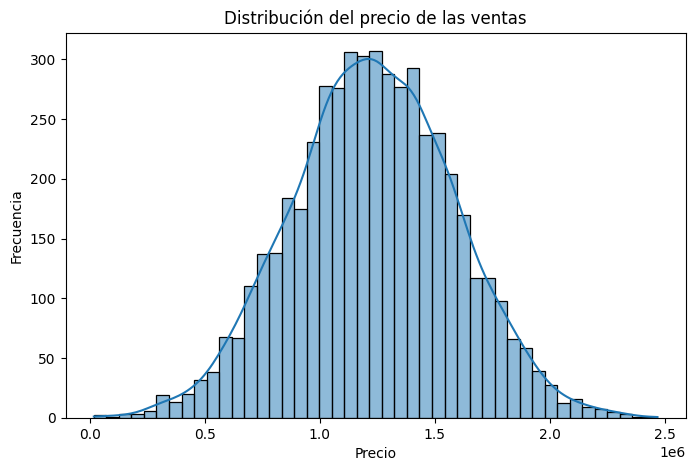

In [37]:
# Para visualizar la distribución del precio de ventas, vemos a visuzalizar el histograma de 
# la variable 'price' y superponer la curva de distribución normal teórica con los mismos 
# parámetros que la muestra.

plt.figure(figsize=(8,5))

sns.histplot(
    data["price"],
    kde=True       # Curva normal teórica superpuesta
)

plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.title("Distribución del precio de las ventas")

plt.show()

La distribución del precio de venta de las viviendas es unimodal y presenta una forma aproximadamente simétrica, similar a una distribución normal. La mayor concentración de observaciones se encuentra alrededor de los 1.2 millones de dólares, observándose una disminución gradual de las frecuencias hacia ambos extremos. No se aprecian asimetrías pronunciadas ni la presencia de múltiples modas.

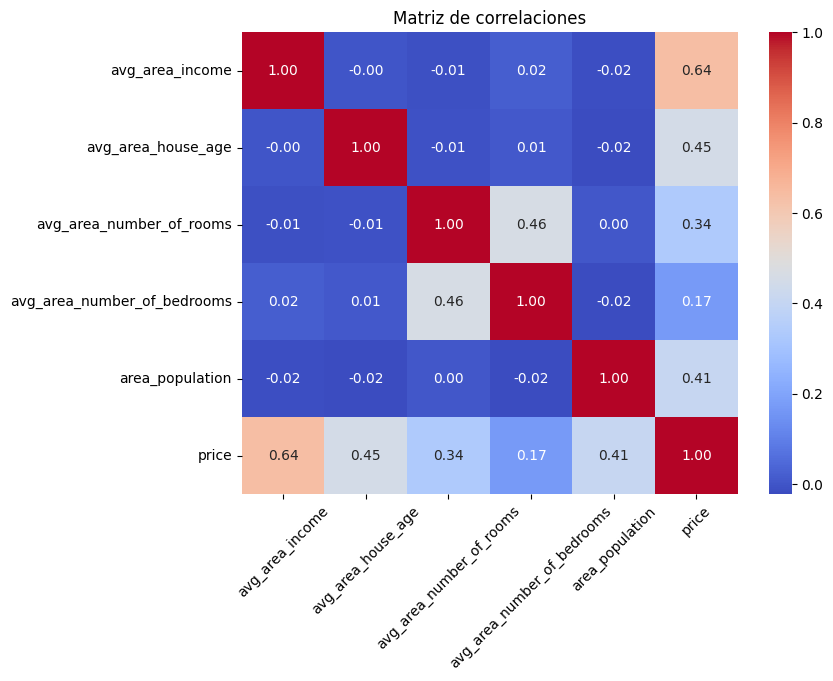

In [39]:
# Vamos a construir una matriz de correlaciones para observar la relación entre 
# las variables numéricas del dataset.

corr = data.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlaciones")
plt.xticks(rotation=45)
plt.show()

A partir de la matriz de correlaciones se observa que la variable `price` presenta su mayor asociación lineal con `avg_area_income`, obteniéndose un coeficiente de correlación de Pearson de aproximadamente 0.64. Esto indica una correlación positiva moderadamente fuerte, por lo que las viviendas ubicadas en áreas con mayores ingresos promedio tienden a presentar precios más elevados.

Asimismo, se observan correlaciones positivas moderadas entre price y avg_area_house_age ($r \cong 0.35$) y entre price y `avg_area_number_of_rooms` ($r\cong 0.34$). Esto sugiere que las viviendas situadas en zonas con casas más antiguas y con un mayor número promedio de ambientes tienden a tener precios más altos, aunque la intensidad de estas asociaciones es considerablemente menor que la observada para el ingreso promedio de la zona.

En consecuencia, las variables más fuertemente correlacionadas con el precio de las viviendas son  `avg_area_income`, seguida por avg_area_house_age y `avg_area_number_of_rooms`. Por esta razón, resulta razonable explorar gráficamente la relación entre `price` y `avg_area_income`, dado que constituye el par de variables con mayor asociación lineal observada.

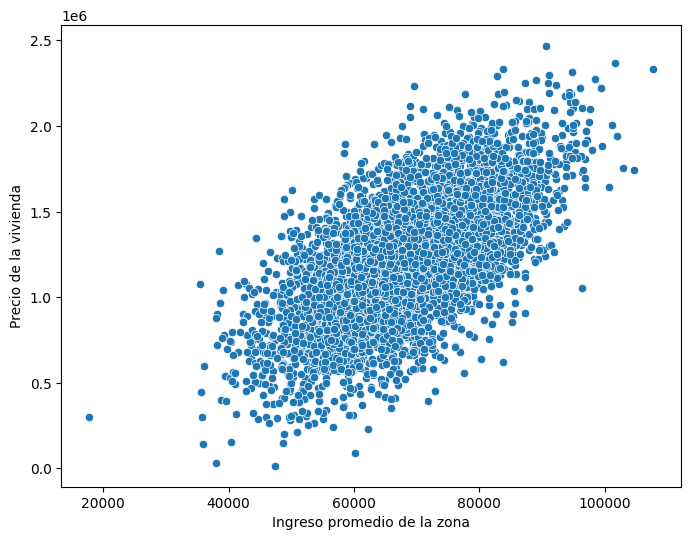

In [41]:
# Elegimos las variables 'price' y 'avg_area_income' para visualizar su relación a través de un 
# diagrama de dispersión.

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=data,
    x="avg_area_income",
    y="price"
)

plt.xlabel("Ingreso promedio de la zona")
plt.ylabel("Precio de la vivienda")

plt.show()

Se observa una tendencia creciente entre ambas variables. A medida que aumenta el ingreso promedio de la zona, también tiende a aumentar el precio de las viviendas. La nube de puntos muestra una asociación lineal positiva consistente con el coeficiente de correlación calculado previamente.

## Parte II

Se propone ajustar inicialmente un modelo de regresión lineal múltiple utilizando como variable respuesta el precio de venta de la vivienda (`price`) y como variables explicativas:

- `avg_area_income`
- `avg_area_house_age`
- `avg_area_number_of_rooms`
- `avg_area_number_of_bedrooms`
- `area_population`

El modelo completo es:

$$Y = \beta_0 + \beta_1 X_{income} + \beta_2 X_{age} + \beta_3 X_{rooms} + \beta_4 X_{bedrooms} + \beta_5 X_{population} + \epsilon.$$

Para determinar cuáles variables contribuyen significativamente a explicar el precio de las viviendas, se analizan los P>|t| asociados a cada coeficiente.

Se consideran significativas aquellas variables cuyo P>|t| es menor que el nivel de significación adoptado (habitualmente 0.05).

In [42]:
modelo = smf.ols(
    formula = 'price ~ avg_area_income + avg_area_house_age + avg_area_number_of_rooms + avg_area_number_of_bedrooms + area_population',
    data = data).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                 1.119e+04
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:11:38   Log-Likelihood:                -64714.
No. Observations:                5000   AIC:                         1.294e+05
Df Residuals:                    4994   BIC:                         1.295e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

En base a lo mencionado, eliminamos la variable `avg_area_number_of_bedrooms` del modelo y obtenemos:

$$Y = \beta_0 + \beta_1 X_{income} + \beta_2 X_{age} + \beta_3 X_{rooms} + \beta_5 X_{population} + \epsilon.$$

In [44]:
modelo2 = smf.ols(
    formula = 'price ~ avg_area_income + avg_area_house_age + avg_area_number_of_rooms + area_population',
    data = data).fit()

print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                 1.398e+04
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:14:45   Log-Likelihood:                -64714.
No. Observations:                5000   AIC:                         1.294e+05
Df Residuals:                    4995   BIC:                         1.295e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

El modelo obtenido es

$$Y = -2.638 \cdot 10^6 + 21.5827 X_{income} + 1.657 \cdot 10^5 X_{age} + 1.216\cdot 10^5 X_{rooms} + 15.1961 X_{population} + \epsilon.$$

Los coeficientes asociados a las variables explicativas resultaron positivos. Esto indica que, manteniendo constantes las restantes variables del modelo, un incremento en cualquiera de ellas se asocia con un aumento esperado en el precio de la vivienda.

En particular:

- Un mayor ingreso promedio de la zona se asocia con mayores precios de las viviendas.
- Una mayor antigüedad promedio de las viviendas se asocia con mayores precios.
- Un mayor número promedio de ambientes se asocia con un incremento en el precio - esperado.
- Un mayor número promedio de habitaciones también se asocia con un aumento esperado del precio.
- Una mayor población de la ciudad se asocia con precios más elevados.

El intercepto representa el precio esperado de una vivienda cuando todas las variables explicativas toman valor cero. En este caso, el valor estimado es aproximadamente $-2.638\cdot 10^6$. Dado que una ciudad con ingreso promedio, antigüedad promedio, cantidad promedio de ambientes, cantidad promedio de habitaciones y población iguales a cero no tiene sentido práctico, el intercepto no posee una interpretación realista en este contexto y debe entenderse principalmente como una constante necesaria para el ajuste del modelo.

Para comparar la bondad de ajuste entre el modelo completo y el modelo reducido se utilizaría el coeficiente $R^2$ ajustado. En el caso del modelo reducido (modelo 2) tenemos un valor de 0.918, lo que nos dice que la variabilidad es de un 91.8%. Mientras que el modelo inicial (modelo 1) es de 0.0918. En ambos casos, el porcentaje es alto. Luego, resulta conveniente el modelo reducido ya que prácticamente utiliza menos variables.

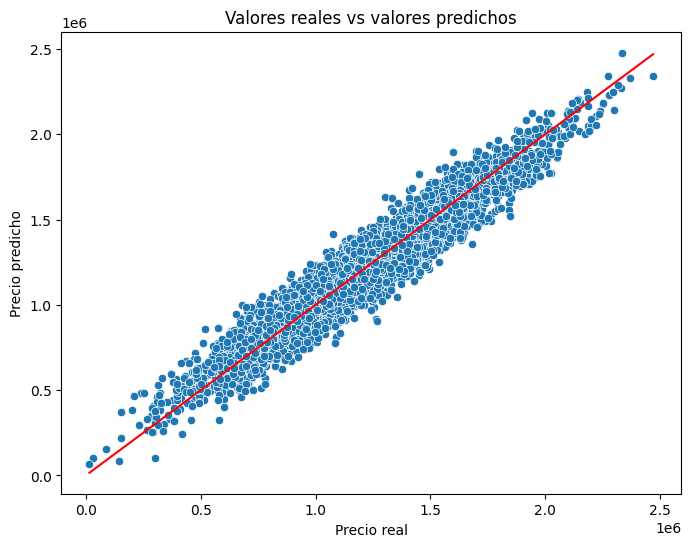

In [47]:
y_real = data["price"]
y_pred = modelo2.predict()

plt.figure(figsize=(8,6))

sns.scatterplot(x=y_real, y=y_pred)

plt.plot(
    [y_real.min(), y_real.max()],
    [y_real.min(), y_real.max()],
    'r-'
)

plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Valores reales vs valores predichos")

plt.show()

Se aprecia una ligera mayor dispersión para los valores más elevados del precio, aunque el comportamiento general sigue siendo satisfactorio y no compromete significativamente la calidad del ajuste.